In [1]:
import os
import shutil
import random
from PIL import Image
import matplotlib.pyplot as plt

In [2]:
source_dir = "dataset/raw"
base_dir = "dataset"

train_dir = os.path.join(base_dir, "train")
val_dir = os.path.join(base_dir, "val")
test_dir = os.path.join(base_dir, "test")

print("Kaynak klasör:", source_dir)
print("Train klasoru:", train_dir)
print("Val klasoru:", val_dir)
print("Test klasoru:", test_dir)

Kaynak klasör: dataset/raw
Train klasoru: dataset\train
Val klasoru: dataset\val
Test klasoru: dataset\test


In [3]:
classes = os.listdir(source_dir)
print("Bulunan sınıflar:")
print(classes)

Bulunan sınıflar:
['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [4]:
for class_name in classes:
    class_path = os.path.join(source_dir, class_name)
    if os.path.isdir(class_path):
        print(class_name, "->", len(os.listdir(class_path)), "goruntu")

cardboard -> 403 goruntu
glass -> 501 goruntu
metal -> 410 goruntu
paper -> 594 goruntu
plastic -> 482 goruntu
trash -> 137 goruntu


In [5]:
split_ratio = (0.7, 0.15, 0.15)

for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    images = os.listdir(class_path)
    random.shuffle(images)

    train_split = int(len(images) * split_ratio[0])
    val_split = int(len(images) * split_ratio[1])

    train_images = images[:train_split]
    val_images = images[train_split:train_split + val_split]
    test_images = images[train_split + val_split:]

    for split_name, split_images in zip(
        ["train", "val", "test"],
        [train_images, val_images, test_images]
    ):
        target_class_dir = os.path.join(base_dir, split_name, class_name)
        os.makedirs(target_class_dir, exist_ok=True)

        for img_name in split_images:
            src_path = os.path.join(class_path, img_name)
            dst_path = os.path.join(target_class_dir, img_name)
            shutil.copy2(src_path, dst_path)

print("Veri ayırma tamamlandı.")

Veri ayırma tamamlandı.


In [6]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(base_dir, split)
    print(f"\n{split.upper()} klasörü:")
    
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if os.path.isdir(class_path):
            print(class_name, "->", len(os.listdir(class_path)), "görüntü")


TRAIN klasörü:
cardboard -> 399 görüntü
glass -> 494 görüntü
metal -> 401 görüntü
paper -> 573 görüntü
plastic -> 440 görüntü
trash -> 125 görüntü

VAL klasörü:
cardboard -> 186 görüntü
glass -> 236 görüntü
metal -> 155 görüntü
paper -> 229 görüntü
plastic -> 136 görüntü
trash -> 35 görüntü

TEST klasörü:
cardboard -> 193 görüntü
glass -> 213 görüntü
metal -> 162 görüntü
paper -> 234 görüntü
plastic -> 134 görüntü
trash -> 41 görüntü


Örnek dosya: dataset\train\cardboard\cardboard1.jpg
Boyut: (512, 384)
Mod: RGB


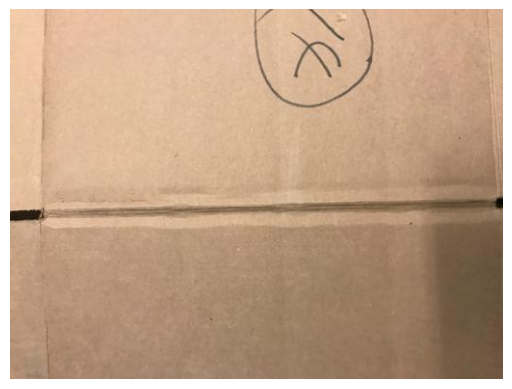

In [7]:
sample_image_path = None

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)
    if os.path.isdir(class_path):
        files = os.listdir(class_path)
        if len(files) > 0:
            sample_image_path = os.path.join(class_path, files[0])
            break

img = Image.open(sample_image_path)

print("Örnek dosya:", sample_image_path)
print("Boyut:", img.size)
print("Mod:", img.mode)

plt.imshow(img)
plt.axis("off")
plt.show()

In [8]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [9]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # tüm resimleri aynı boyuta getir
    transforms.ToTensor(),           # image → sayı tensor
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

In [10]:
train_dataset = datasets.ImageFolder(
    root="dataset/train",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root="dataset/val",
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root="dataset/test",
    transform=transform
)

In [11]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [12]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)
print("Labels:", labels[:10])

Image shape: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 0, 3, 3, 4, 1, 4, 3, 5, 4])


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..0.96862745].


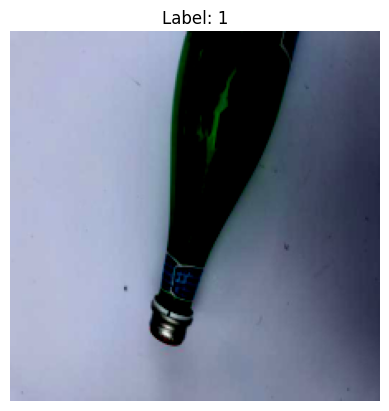

In [13]:
import matplotlib.pyplot as plt

img = images[0].permute(1, 2, 0)  # tensor → image

plt.imshow(img)
plt.title(f"Label: {labels[0].item()}")
plt.axis("off")
plt.show()

In [14]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [15]:
model = SimpleCNN(num_classes=6)
print(model)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=50176, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=6, bias=True)
  )
)


In [16]:
outputs = model(images)
print(outputs.shape)

torch.Size([32, 6])


In [17]:
torch.Size([32, 6])

torch.Size([32, 6])

In [18]:
preds = torch.argmax(outputs, dim=1)
print("Tahminler:", preds[:10])
print("Gerçekler :", labels[:10])

Tahminler: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Gerçekler : tensor([1, 0, 3, 3, 4, 1, 4, 3, 5, 4])


In [19]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [20]:
model.train()

images, labels = next(iter(train_loader))

optimizer.zero_grad()      # eski gradientleri temizle
outputs = model(images)    # tahmin üret
loss = criterion(outputs, labels)   # hatayı hesapla
loss.backward()            # geri yayılım
optimizer.step()           # ağırlıkları güncelle

print("Loss:", loss.item())

Loss: 1.7922829389572144


In [21]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

Epoch 1/3, Loss: 1.4593
Epoch 2/3, Loss: 1.0116
Epoch 3/3, Loss: 0.7956


In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print(f"Validation Accuracy: {accuracy:.4f}")

Validation Accuracy: 0.7861


In [23]:
from torchvision import models

model = models.resnet18(pretrained=True)

C:\Users\Kadir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Kadir\AppData\Local\Programs\Python\Python311\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\Kadir/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████████████████████████████████████████████████████████████████████| 44.7M/44.7M [00:28<00:00, 1.65MB/s]


In [24]:
import torch.nn as nn

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, 6)

In [25]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [26]:
epochs = 3

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")

Epoch 1, Loss: 0.6146
Epoch 2, Loss: 0.1184
Epoch 3, Loss: 0.0426


In [27]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print(f"ResNet Validation Accuracy: {accuracy:.4f}")

ResNet Validation Accuracy: 0.9939


In [28]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total

print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9928
